<h1><b>ACV Refrigerant Leak Data Preprocessing</b></h1>

<h4><b>Background Information</b></h4>

The ACV subsystem in NEBULA X Problem Statement 3 concerns air-conditioning units that lose
refrigerant. Each case is one workbook of telemetry for every car of a train, and one car per case is
labelled as leaking. Predictions rank all cars of a case from most to least likely to be leaking, and
the rank of the leaking car is scored with a linear rank decay. The ACV exploratory data analysis found
that the workbooks come from different car models with different parameter names, sampling intervals
and invalid-value conventions.

<h4><b>Objective</b></h4>

This notebook turns the seven workbooks into one validated, harmonised dataset and a table of
case-and-car features for ranking models. It maps each car model's parameters to common fields, masks
invalid readings without filling them, aligns every case to a common one-minute grid, builds
contemporaneous peer comparisons, standardises features within each case, attaches labels and
leave-one-case-out folds, and saves the results. No model is trained and no Test ranking is produced.

<h4><b>Project Workflow</b></h4>

The workflow configures the environment, inventories and loads the workbooks, and validates metadata,
headers, parameter sets, data types, timestamps, missing values, value domains, numeric ranges and
labels. It then harmonises the schemas, cleans invalid and empty readings, aligns the cases in time,
constructs peer and operating-context features, summarises them per case and car, cross-checks the
labels, and exports the results with a manifest.

<h4><b>Dataset Used</b></h4>

`PS3/02_Datasets/ACV` contains six labelled Train workbooks (`acv_case_01.xlsx` to
`acv_case_06.xlsx`), `Train_Labels.csv` naming the leaking car of each, and one unlabelled Test
workbook (`acv_test_case.xlsx`). Car telemetry columns are named `Car NN - <parameter>`; `Time`,
`Car model` and `Train number` are shared metadata. Car identifiers are kept as two-digit strings.
Outputs are written to `data/processed/acv`, which is excluded from version control.

<h4><b>Table of Contents</b></h4>
<ul>
  <li><a href="#section-1">Section 1: Environment Setup and Configuration</a>
    <ul>
      <li><a href="#1-1">1.1 Libraries and Display Settings</a></li>
      <li><a href="#1-2">1.2 Dataset Location and Output Directory</a></li>
      <li><a href="#1-3">1.3 Environment Versions</a></li>
    </ul>
  </li>
  <li><a href="#section-2">Section 2: Data Loading and Inventory</a>
    <ul>
      <li><a href="#2-1">2.1 Workbook Inventory</a></li>
      <li><a href="#2-2">2.2 Workbook Loading</a></li>
      <li><a href="#2-3">2.3 Label Loading</a></li>
    </ul>
  </li>
  <li><a href="#section-3">Section 3: Data Inspection and Validation</a>
    <ul>
      <li><a href="#3-1">3.1 Dimensions and Case Metadata</a></li>
      <li><a href="#3-2">3.2 Header Parsing and Car Coverage</a></li>
      <li><a href="#3-3">3.3 Parameter Sets by Case</a></li>
      <li><a href="#3-4">3.4 Data Types and Mixed-Type Parameters</a></li>
      <li><a href="#3-5">3.5 Timestamp Validation</a></li>
      <li><a href="#3-6">3.6 Missing Values</a></li>
      <li><a href="#3-7">3.7 Categorical Value Domains</a></li>
      <li><a href="#3-8">3.8 Numeric Ranges and Invalid Values</a></li>
      <li><a href="#3-9">3.9 Label Validation</a></li>
    </ul>
  </li>
  <li><a href="#section-4">Section 4: Schema Harmonisation</a>
    <ul>
      <li><a href="#4-1">4.1 Parameter Mapping</a></li>
      <li><a href="#4-2">4.2 Long-Format Assembly</a></li>
      <li><a href="#4-3">4.3 Running-Mode Groups</a></li>
    </ul>
  </li>
  <li><a href="#section-5">Section 5: Cleaning</a>
    <ul>
      <li><a href="#5-1">5.1 Validity Masking</a></li>
      <li><a href="#5-2">5.2 Empty Readings</a></li>
      <li><a href="#5-3">5.3 Train-Level Outdoor Temperature</a></li>
      <li><a href="#5-4">5.4 Cabin Temperature Coverage</a></li>
    </ul>
  </li>
  <li><a href="#section-6">Section 6: Time Alignment</a>
    <ul>
      <li><a href="#6-1">6.1 One-Minute Grid</a></li>
      <li><a href="#6-2">6.2 Grid Coverage</a></li>
    </ul>
  </li>
  <li><a href="#section-7">Section 7: Feature Construction</a>
    <ul>
      <li><a href="#7-1">7.1 Contemporaneous Peer Baseline</a></li>
      <li><a href="#7-2">7.2 Operating Context</a></li>
      <li><a href="#7-3">7.3 Case-and-Car Summary Features</a></li>
      <li><a href="#7-4">7.4 Within-Case Standardisation</a></li>
      <li><a href="#7-5">7.5 Labels and Case Folds</a></li>
      <li><a href="#7-6">7.6 Refrigerant Pressure Cross-Check</a></li>
      <li><a href="#7-7">7.7 Labelled-Car Rank Screen</a></li>
      <li><a href="#7-8">7.8 Peer Difference Overview</a></li>
    </ul>
  </li>
  <li><a href="#section-8">Section 8: Export</a>
    <ul>
      <li><a href="#8-1">8.1 Output Tables</a></li>
      <li><a href="#8-2">8.2 Manifest</a></li>
      <li><a href="#8-3">8.3 Export Verification</a></li>
    </ul>
  </li>
  <li><a href="#section-9">Section 9: Conclusions</a>
    <ul>
      <li><a href="#9-1">9.1 Prepared Outputs</a></li>
      <li><a href="#9-2">9.2 Data Quality Findings</a></li>
      <li><a href="#9-3">9.3 Implications for Modelling</a></li>
    </ul>
  </li>
</ul>

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-1" style="color: black;"><b>Section 1: Environment Setup and Configuration</b></h2>
</div>

This section imports the required libraries, fixes display settings and the random seed, and locates
the dataset and the output directory.

<blockquote><h3 id="1-1"><b>1.1 Libraries and Display Settings</b></h3></blockquote>

In the cell below, the numerical, spreadsheet and plotting libraries are imported, and shared constants
define the random seed and the plot colours.

In [1]:
from pathlib import Path
import os
import re
import json
import time
import hashlib
import platform
import importlib.metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

SEED = 2026
COLORS = {'Affected car': '#d95f38', 'Other car': '#16857b', 'Test car': '#8256b3'}
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.constrained_layout.use': True})
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 120)
pd.set_option('display.width', 170)

<blockquote><h3 id="1-2"><b>1.2 Dataset Location and Output Directory</b></h3></blockquote>

The ACV folder is found from the working directory, or from `TFD_PS3_DIR` when that variable names the
PS3 folder or its `02_Datasets` folder. Outputs go to `data/processed/acv` under the repository root
unless `TFD_PROCESSED_DIR` overrides the parent folder. Paths are displayed relative to the repository
so that saved outputs carry no machine-specific prefix.

In [2]:
def find_repo_root():
    """Nearest ancestor of the working directory that holds `pyproject.toml`."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / 'pyproject.toml').is_file():
            return base
    return Path.cwd()


def find_dataset(subsystem):
    """Locate a PS3 subsystem folder.

    `TFD_PS3_DIR` may name the PS3 folder or its `02_Datasets` folder. Otherwise the working directory
    and its parents are searched for `problem-statement/PS3/02_Datasets`, `PS3/02_Datasets` and
    `02_Datasets`.
    """
    if os.environ.get('TFD_PS3_DIR'):
        root = Path(os.environ['TFD_PS3_DIR']).expanduser()
        candidates = [root / subsystem, root / '02_Datasets' / subsystem]
    else:
        suffixes = ['problem-statement/PS3/02_Datasets', 'PS3/02_Datasets', '02_Datasets']
        candidates = [base / suffix / subsystem for base in [Path.cwd(), *Path.cwd().parents] for suffix in suffixes]
    for candidate in candidates:
        if candidate.is_dir():
            return candidate.resolve()
    raise FileNotFoundError(f'{subsystem} not found; set TFD_PS3_DIR to the PS3 or 02_Datasets folder.')


def shown(path):
    """Path relative to the repository root, or only its name when it lies outside the repository."""
    try:
        return Path(path).resolve().relative_to(REPO_ROOT).as_posix()
    except ValueError:
        return Path(path).name


REPO_ROOT = find_repo_root()
ACV_DIR = find_dataset('ACV')
OUT_DIR = Path(os.environ.get('TFD_PROCESSED_DIR', REPO_ROOT / 'data' / 'processed')) / 'acv'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('Dataset:', shown(ACV_DIR))
print('Output: ', shown(OUT_DIR))

Dataset: problem-statement/PS3/02_Datasets/ACV
Output:  data/processed/acv


<blockquote><h3 id="1-3"><b>1.3 Environment Versions</b></h3></blockquote>

In the cell below, the Python and package versions are recorded so that the saved results can be
reproduced.

In [3]:
versions = {'Python': platform.python_version(), **{name: importlib.metadata.version(name) for name in ['numpy', 'pandas', 'openpyxl', 'pyarrow', 'matplotlib']}}
display(pd.Series(versions, name='version').to_frame())

,version
Python,3.12.14
numpy,2.4.6
pandas,2.3.3
openpyxl,3.1.5
pyarrow,25.0.0
matplotlib,3.11.2


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-2" style="color: black;"><b>Section 2: Data Loading and Inventory</b></h2>
</div>

This section lists and fingerprints the workbooks, loads each one from its only sheet, and loads the
Train labels with car identifiers kept as text.

<blockquote><h3 id="2-1"><b>2.1 Workbook Inventory</b></h3></blockquote>

In the cell below, every workbook under `Train` and `Test` is listed with its size, sheet names and a
SHA-256 fingerprint. A workbook with more than one sheet would require review, because only the first
sheet is read.

In [4]:
workbook_paths = sorted((ACV_DIR / 'Train').glob('*.xlsx')) + sorted((ACV_DIR / 'Test').glob('*.xlsx'))
inventory = []
for path in workbook_paths:
    with pd.ExcelFile(path, engine='openpyxl') as book:
        sheets = book.sheet_names
    inventory.append({'workbook': path.name, 'dataset': path.parent.name, 'sheets': len(sheets),
                      'size_MB': round(path.stat().st_size / 1e6, 2),
                      'sha256': hashlib.sha256(path.read_bytes()).hexdigest()})
inventory = pd.DataFrame(inventory)
assert inventory['sheets'].eq(1).all(), 'A workbook has more than one sheet; review before loading.'
display(inventory.assign(sha256=inventory['sha256'].str[:16]))

,workbook,dataset,sheets,size_MB,sha256
0,acv_case_01.xlsx,Train,1,1.72,d0657d45b52d12db
1,acv_case_02.xlsx,Train,1,2.30,869107ed17735efb
2,acv_case_03.xlsx,Train,1,2.06,07801fb08e6fc365
3,acv_case_04.xlsx,Train,1,33.80,650676c44e8f5979
4,acv_case_05.xlsx,Train,1,1.64,cc994bf2a1a197e0
5,acv_case_06.xlsx,Train,1,0.77,6066b6882bf92af6
6,acv_test_case.xlsx,Test,1,2.22,948a5bcbb0bdc22c


<blockquote><h3 id="2-2"><b>2.2 Workbook Loading</b></h3></blockquote>

In the cell below, each workbook is read in full and its load time recorded. A short case identifier
such as `case_01` or `test_case` is derived from each file name.

In [5]:
CASE = {name: name.removeprefix('acv_').removesuffix('.xlsx') for name in inventory['workbook']}
DATASET = dict(zip(inventory['workbook'], inventory['dataset']))
workbooks, load_times = {}, {}
for path in workbook_paths:
    start = time.perf_counter()
    workbooks[path.name] = pd.read_excel(path, sheet_name=0, engine='openpyxl')
    load_times[path.name] = round(time.perf_counter() - start, 1)
display(pd.DataFrame({'case': CASE, 'rows': {n: len(f) for n, f in workbooks.items()},
                      'columns': {n: f.shape[1] for n, f in workbooks.items()}, 'load_s': load_times}))

,case,rows,columns,load_s
acv_case_01.xlsx,case_01,6999,67,3.1
acv_case_02.xlsx,case_02,9187,67,4.1
acv_case_03.xlsx,case_03,8310,67,3.5
acv_case_04.xlsx,case_04,22262,483,49.1
acv_case_05.xlsx,case_05,6972,67,3.2
acv_case_06.xlsx,case_06,3263,67,1.5
acv_test_case.xlsx,test_case,9082,67,4.1


<blockquote><h3 id="2-3"><b>2.3 Label Loading</b></h3></blockquote>

In the cell below, the Train labels are read as strings so that the two-digit car identifiers keep
their leading zeros.

In [6]:
labels = pd.read_csv(ACV_DIR / 'Train_Labels.csv', dtype=str)
labels['case'] = labels['filename'].map(CASE)
display(labels)

,filename,faulty_car,case
0,acv_case_01.xlsx,01,case_01
1,acv_case_02.xlsx,02,case_02
2,acv_case_03.xlsx,03,case_03
3,acv_case_04.xlsx,01,case_04
4,acv_case_05.xlsx,04,case_05
5,acv_case_06.xlsx,06,case_06


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-3" style="color: black;"><b>Section 3: Data Inspection and Validation</b></h2>
</div>

This section establishes data quality before any harmonisation: case metadata, header structure,
parameter sets, data types, timestamps, missing values, categorical domains, numeric ranges and label
integrity.

<blockquote><h3 id="3-1"><b>3.1 Dimensions and Case Metadata</b></h3></blockquote>

In the cell below, each case is summarised by its size, car model, train number and time range. Car
model and train number are constant within a workbook when a single value is listed.

In [7]:
case_meta = pd.DataFrame([{
    'workbook': name, 'case': CASE[name], 'dataset': DATASET[name], 'rows': len(frame), 'columns': frame.shape[1],
    'car_model': ', '.join(map(str, frame['Car model'].dropna().unique())),
    'train_number': ', '.join(map(str, frame['Train number'].dropna().unique())),
    'first': frame['Time'].min(), 'last': frame['Time'].max(),
} for name, frame in workbooks.items()])
display(case_meta)

,workbook,case,dataset,rows,columns,car_model,train_number,first,last
0,acv_case_01.xlsx,case_01,Train,6999,67,A,620,2023-05-18 00:00:00,2023-05-21 20:49:30
1,acv_case_02.xlsx,case_02,Train,9187,67,A,620,2020-07-09 00:00:00,2020-07-12 23:35:00
2,acv_case_03.xlsx,case_03,Train,8310,67,A,619,2021-09-30 05:16:00,2021-10-03 23:59:30
3,acv_case_04.xlsx,case_04,Train,22262,483,B,208,2023-08-15 07:06:50,2023-08-18 20:41:00
4,acv_case_05.xlsx,case_05,Train,6972,67,C,407,2021-03-03 06:19:00,2021-03-06 23:59:30
5,acv_case_06.xlsx,case_06,Train,3263,67,C,408,2020-07-06 08:42:00,2020-07-08 23:59:30
6,acv_test_case.xlsx,test_case,Test,9082,67,A,620,2021-06-24 00:00:00,2021-06-27 23:59:30


<blockquote><h3 id="3-2"><b>3.2 Header Parsing and Car Coverage</b></h3></blockquote>

In the cell below, every column name is parsed with the pattern `Car NN - <parameter>`, and columns that
do not match are treated as metadata. The table lists the metadata columns, the number of cars, the
order in which cars appear in the headers, and the number of parameters per car.

In [8]:
CAR_COLUMN = re.compile(r'^Car (\d{2}) - (.+)$')


def parse_headers(frame):
    """One row per column: the column name, and its car and parameter when it is car telemetry."""
    rows = []
    for column in frame.columns:
        match = CAR_COLUMN.match(str(column))
        rows.append((column, *match.groups()) if match else (column, None, None))
    return pd.DataFrame(rows, columns=['column', 'car', 'parameter'])


headers = {name: parse_headers(frame) for name, frame in workbooks.items()}
coverage = pd.DataFrame({CASE[name]: {
    'metadata columns': ', '.join(h.loc[h['car'].isna(), 'column']),
    'cars': h['car'].nunique(),
    'car order in headers': ' '.join(h['car'].dropna().drop_duplicates()),
    'parameters per car': '-'.join(map(str, sorted({h.dropna().groupby('car')['parameter'].nunique().min(),
                                                    h.dropna().groupby('car')['parameter'].nunique().max()}))),
} for name, h in headers.items()}).T
display(coverage)

,metadata columns,cars,car order in headers,parameters per car
case_01,"Car model, Train number, Time",8,08 01 04 02 07 06 03 05,8
case_02,"Car model, Train number, Time",8,08 01 04 02 07 06 03 05,8
case_03,"Car model, Train number, Time",8,08 01 04 02 07 06 03 05,8
case_04,"Car model, Train number, Time",8,08 01 02 07 03 06 05 04,59-62
case_05,"Car model, Train number, Time",8,04 05 08 01 06 02 07 03,8
case_06,"Car model, Train number, Time",8,04 05 08 01 06 02 07 03,8
test_case,"Car model, Train number, Time",8,08 01 04 02 07 06 03 05,8


<blockquote><h3 id="3-3"><b>3.3 Parameter Sets by Case</b></h3></blockquote>

In the cell below, the number of cars carrying each parameter is tabulated per case for the parameters
of the compact schema, and the parameters shared by every workbook and those found only in the rich
schema are counted.

In [9]:
presence = pd.DataFrame({CASE[name]: h.dropna().groupby('parameter')['car'].nunique()
                         for name, h in headers.items()}).fillna(0).astype(int)
compact = presence.drop(columns='case_04')
display(presence.loc[(compact > 0).any(axis=1)])
print('Parameters present in every workbook:', list(presence.index[(presence > 0).all(axis=1)]))
print('Parameters present only in case_04:', int(((presence['case_04'] > 0) & (compact == 0).all(axis=1)).sum()),
      'of', int((presence['case_04'] > 0).sum()))

,case_01,case_02,case_03,case_04,case_05,case_06,test_case
parameter,,,,,,,
ACV Control Temperature (Cooling),8,8,8,0,8,8,8
ACV Control Temperature (Heating),8,8,8,0,8,8,8
ACV Information Valid,8,8,8,0,8,8,8
ACV Running Mode,8,8,8,8,8,8,8
ACV Setting Mode,8,8,8,0,8,8,8
Indoor Average Temperature,8,8,8,0,8,8,8
Load Halved,8,8,8,0,8,8,8
Outdoor Average Temperature,8,8,8,0,0,0,8
Outside Temperature Sensor Reading,0,0,0,0,8,8,0


Parameters present in every workbook: ['ACV Running Mode']
Parameters present only in case_04: 62 of 63


<blockquote><h3 id="3-4"><b>3.4 Data Types and Mixed-Type Parameters</b></h3></blockquote>

In the cell below, the column data types of each workbook are counted, and every parameter that holds
both numeric and text values is listed with its distinct text values. Text inside a numeric parameter
must be converted to missing before any calculation.

In [10]:
display(pd.DataFrame({CASE[n]: f.dtypes.astype(str).value_counts() for n, f in workbooks.items()}).fillna(0).astype(int))
type_rows = []
for name, frame in workbooks.items():
    for parameter, columns in headers[name].dropna().groupby('parameter')['column']:
        values = pd.concat([frame[c] for c in columns], ignore_index=True).dropna()
        is_text = values.map(lambda v: isinstance(v, str))
        if is_text.any() and not is_text.all():
            type_rows.append({'case': CASE[name], 'parameter': parameter, 'numeric values': int((~is_text).sum()),
                              'text values': int(is_text.sum()),
                              'distinct text': ', '.join(sorted(values[is_text].unique())[:4])})
display(pd.DataFrame(type_rows))

,case_01,case_02,case_03,case_04,case_05,case_06,test_case
datetime64[ns],1,1,1,1,1,1,1
float64,32,32,24,356,26,26,32
int64,1,1,9,1,1,1,1
object,33,33,33,125,39,39,33


,case,parameter,numeric values,text values,distinct text
0,case_05,Outside Temperature Sensor Reading,12596,37788,Invalid
1,case_06,Outside Temperature Sensor Reading,5630,16890,Invalid


<blockquote><h3 id="3-5"><b>3.5 Timestamp Validation</b></h3></blockquote>

In the cell below, each `Time` column is checked for type, missing values, duplicates and ordering. The
modal sampling step, the number of steps that differ from it, the gaps longer than five minutes and
the total span describe the sampling of each case.

In [11]:
time_rows = []
for name, frame in workbooks.items():
    t = frame['Time']
    step = t.diff().dt.total_seconds().dropna()
    modal = step.mode().iloc[0]
    time_rows.append({'case': CASE[name], 'dtype': str(t.dtype), 'missing': int(t.isna().sum()),
                      'duplicates': int(t.duplicated().sum()), 'monotonic': t.is_monotonic_increasing,
                      'modal step (s)': modal, 'off-modal steps': int((step != modal).sum()),
                      'gaps over 5 min': int((step > 300).sum()), 'longest gap (min)': round(step.max() / 60, 1),
                      'span (h)': round((t.max() - t.min()).total_seconds() / 3600, 1)})
display(pd.DataFrame(time_rows).set_index('case'))

,dtype,missing,duplicates,monotonic,modal step (s),off-modal steps,gaps over 5 min,longest gap (min),span (h)
case,,,,,,,,,
case_01,datetime64[ns],0,0,True,30.0,237,6,579.5,92.8
case_02,datetime64[ns],0,0,True,30.0,143,9,358.5,95.6
case_03,datetime64[ns],0,0,True,30.0,159,5,569.5,90.7
case_04,datetime64[ns],0,0,True,10.0,48,9,652.2,85.6
case_05,datetime64[ns],0,0,True,30.0,119,10,680.5,89.7
case_06,datetime64[ns],0,0,True,30.0,119,9,480.0,63.3
test_case,datetime64[ns],0,0,True,30.0,193,7,370.5,96.0


<blockquote><h3 id="3-6"><b>3.6 Missing Values</b></h3></blockquote>

In the cell below, a car is counted as silent at a timestamp when all of its columns are empty. The
table gives the percentage of timestamps at which each car is silent, the percentage at which every
car is silent, and the overall percentage of empty car cells.

In [12]:
silent = {}
for name, frame in workbooks.items():
    h = headers[name].dropna()
    per_car = {car: frame[list(cols)].isna().all(axis=1) for car, cols in h.groupby('car')['column']}
    row = {f'car {car}': round(s.mean() * 100, 1) for car, s in per_car.items()}
    row['all cars silent'] = round(pd.concat(per_car, axis=1).all(axis=1).mean() * 100, 1)
    row['empty car cells'] = round(frame[h['column']].isna().to_numpy().mean() * 100, 1)
    silent[CASE[name]] = row
display(pd.DataFrame(silent).T)

,car 01,car 02,car 03,car 04,car 05,car 06,car 07,car 08,all cars silent,empty car cells
case_01,9.7,9.7,9.7,9.7,9.7,9.7,9.7,9.7,9.7,9.7
case_02,8.8,8.8,8.8,8.8,8.8,8.8,8.8,8.8,8.8,8.8
case_03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
case_04,1.9,1.9,1.9,1.9,100.0,100.0,100.0,100.0,1.9,50.9
case_05,9.7,9.7,9.7,9.7,9.7,9.7,9.7,9.7,9.7,9.7
case_06,13.7,13.7,13.7,13.7,13.7,13.7,13.7,13.7,13.7,13.7
test_case,11.8,11.8,11.8,11.8,11.8,11.8,11.8,11.8,11.8,11.8


<blockquote><h3 id="3-7"><b>3.7 Categorical Value Domains</b></h3></blockquote>

In the cell below, the observed values of the running mode, setting mode, validity and load parameters
are counted per case. These domains define the mappings and masks applied in Sections 4 and 5.

In [13]:
CATEGORICAL = ['ACV Running Mode', 'ACV Setting Mode', 'ACV Control Mode', 'ACV Information Valid',
               'Load Halved', 'Load Shedding']
domain_rows = []
for name, frame in workbooks.items():
    h = headers[name].dropna()
    for parameter in CATEGORICAL:
        columns = h.loc[h['parameter'].eq(parameter), 'column']
        if len(columns):
            counts = pd.concat([frame[c] for c in columns]).value_counts()
            domain_rows += [{'case': CASE[name], 'parameter': parameter, 'value': v, 'readings': n}
                            for v, n in counts.items()]
domains = pd.DataFrame(domain_rows).pivot_table(index=['parameter', 'value'], columns='case',
                                                values='readings', aggfunc='sum', fill_value=0)
display(domains)

case                                         case_01  case_02  case_03  case_04  case_05  case_06  test_case
parameter             value                                                                                 
ACV Control Mode      Centralized Control          0        0        0    87389        0        0          0
ACV Information Valid Invalid                     25       44        1        0        0        0         25
                      Valid                    50551    67012    66479        0    50384    22520      64087
ACV Running Mode      Automatic Cooling        46760    66305    65587        0    49686    20979      62628
                      Emergency Ventilation       96      104        3      152      649     1299        145
                      Full Cooling                34        0        0    56209        5      128        344
                      Half Cooling                 0        0       13    27790        1        0          0
                      Invalid                     56       49        1        0        0        0         26
                      Self-Check                   0        0        0        4        0        0          0
                      Stop                      3630      598      352        0       34       24        969
                      Stopped                      0        0        0     1416        0        0          0
                      Ventilation                  0        0      524     1818        9       90          0
ACV Setting Mode      Centralized Control      46885    65179    66123        0    43913    15892      62854
                      Invalid                     25       44        1        0        0        0         25
                      Manual Control            3666     1833      356        0     6471     6628       1233
Load Halved           Normal                   50576    67056    66480        0    50384    22520      64112
Load Shedding         No Load Shedding             0        0        0    87389        0        0          0

<blockquote><h3 id="3-8"><b>3.8 Numeric Ranges and Invalid Values</b></h3></blockquote>

In the cell below, every temperature parameter is converted to numbers, with text treated as missing,
and summarised by count, range, zero readings and negative readings. Zero and negative temperatures
are implausible for a passenger saloon and are candidates for invalid-value conventions.

In [14]:
TEMPERATURES = ['Indoor Average Temperature', 'Passenger Cabin Temperature Detected Value',
                'Observation Area Temperature Detected Value', 'Outdoor Average Temperature',
                'Outside Temperature Sensor Reading', 'Fresh Air Temperature Detected Value',
                'ACV Control Temperature (Cooling)', 'Target Temperature Value']
range_rows = []
for name, frame in workbooks.items():
    h = headers[name].dropna()
    for parameter in TEMPERATURES:
        columns = h.loc[h['parameter'].eq(parameter), 'column']
        if len(columns):
            v = pd.concat([pd.to_numeric(frame[c], errors='coerce') for c in columns])
            range_rows.append({'case': CASE[name], 'parameter': parameter, 'numeric readings': int(v.notna().sum()),
                               'min': v.min(), 'median': v.median(), 'max': v.max(),
                               'zeros': int(v.eq(0).sum()), 'negatives': int(v.lt(0).sum())})
display(pd.DataFrame(range_rows).set_index(['parameter', 'case']).sort_index())

numeric readings   min  median   max  zeros  negatives
parameter                                   case                                                             
ACV Control Temperature (Cooling)           case_01               50576   0.0    24.0  26.0     25          0
                                            case_02               67056   0.0    24.0  26.0     44          0
                                            case_03               66480   0.0    24.0  27.0      1          0
                                            case_05               50384  20.0    24.0  26.0      0          0
                                            case_06               22520  20.0    23.5  25.0      0          0
                                            test_case             64112   0.0    24.0  26.0     25          0
Fresh Air Temperature Detected Value        case_04               87389  24.0    33.0  44.0      0          0
Indoor Average Temperature                  case_01               50576   0.0    24.0  32.5     25          0
                                            case_02               67056   0.0    24.0  29.0     44          0
                                            case_03               66480   0.0    24.5  30.5      1          0
                                            case_05               50384  17.0    23.0  26.5      0          0
                                            case_06               22520  19.0    24.0  34.0      0          0
                                            test_case             64112   0.0    24.0  29.5     25          0
Observation Area Temperature Detected Value case_04               87389 -50.0   -50.0  29.0      0      65540
Outdoor Average Temperature                 case_01               50576   0.0    28.5  35.5     25          0
                                            case_02               67056   0.0    32.5  39.0     44          0
                                            case_03               66480   0.0    31.5  38.5      1          0
                                            test_case             64112   0.0    29.5  37.5     25          0
Outside Temperature Sensor Reading          case_05               12596  15.2    23.2  35.2      0          0
                                            case_06                5630  30.2    36.2  46.2      0          0
Passenger Cabin Temperature Detected Value  case_04               87389  20.0    26.0  29.0      0          0
Target Temperature Value                    case_04               87389  22.0    26.0  28.0      0          0

<blockquote><h3 id="3-9"><b>3.9 Label Validation</b></h3></blockquote>

In the cell below, each label is checked to refer to a Train workbook, to name a car present in that
workbook's headers, and to name a car with at least one non-empty reading. Every Train workbook must
have exactly one label.

In [15]:
train_cases = sorted(case_meta.loc[case_meta['dataset'].eq('Train'), 'case'])
label_checks = labels.assign(
    train_workbook=labels['case'].isin(train_cases),
    car_in_headers=[car in set(headers[f]['car'].dropna()) for f, car in zip(labels['filename'], labels['faulty_car'])],
    car_has_readings=[workbooks[f][headers[f].loc[headers[f]['car'].eq(car), 'column']].notna().any().any()
                      for f, car in zip(labels['filename'], labels['faulty_car'])],
)
assert sorted(labels['case']) == train_cases and labels['case'].is_unique, 'Each Train case needs exactly one label.'
display(label_checks)

,filename,faulty_car,case,train_workbook,car_in_headers,car_has_readings
0,acv_case_01.xlsx,01,case_01,True,True,True
1,acv_case_02.xlsx,02,case_02,True,True,True
2,acv_case_03.xlsx,03,case_03,True,True,True
3,acv_case_04.xlsx,01,case_04,True,True,True
4,acv_case_05.xlsx,04,case_05,True,True,True
5,acv_case_06.xlsx,06,case_06,True,True,True


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-4" style="color: black;"><b>Section 4: Schema Harmonisation</b></h2>
</div>

This section maps the three parameter sets onto common fields, reshapes all cases into one long table
with a row per case, timestamp and car, and groups the running modes into operating states. The
mappings follow the ACV exploratory data analysis; they are semantic correspondences, not confirmed
sensor equivalences.

<blockquote><h3 id="4-1"><b>4.1 Parameter Mapping</b></h3></blockquote>

In the cell below, each common field lists the source parameters that may supply it. Every car of every
workbook is checked to match at most one source per field, and the resulting mapping is displayed per
case. `(absent)` marks a field that a workbook does not provide.

In [16]:
ALIASES = {
    'indoor': ['Indoor Average Temperature', 'Passenger Cabin Temperature Detected Value'],
    'outdoor': ['Outdoor Average Temperature', 'Outside Temperature Sensor Reading',
                'Fresh Air Temperature Detected Value'],
    'target': ['ACV Control Temperature (Cooling)', 'Target Temperature Value'],
    'mode': ['ACV Running Mode'],
    'setting': ['ACV Setting Mode', 'ACV Control Mode'],
    'valid': ['ACV Information Valid'],
    'load': ['Load Halved', 'Load Shedding'],
}
mapping_rows = []
for name in workbooks:
    for car, block in headers[name].dropna().groupby('car'):
        column_of = dict(zip(block['parameter'], block['column']))
        for field, aliases in ALIASES.items():
            found = [p for p in aliases if p in column_of]
            assert len(found) <= 1, f'Ambiguous mapping: {name}, car {car}, {field}'
            mapping_rows.append({'case': CASE[name], 'workbook': name, 'car': car, 'field': field,
                                 'source': found[0] if found else None,
                                 'column': column_of[found[0]] if found else None})
mapping = pd.DataFrame(mapping_rows)
display(mapping.groupby(['case', 'field'])['source']
        .agg(lambda s: ' / '.join(sorted(set(s.dropna()))) or '(absent)').unstack('field')[list(ALIASES)])

field,indoor,outdoor,target,mode,setting,valid,load
case,,,,,,,
case_01,Indoor Average Temperature,Outdoor Average Temperature,ACV Control Temperature (Cooling),ACV Running Mode,ACV Setting Mode,ACV Information Valid,Load Halved
case_02,Indoor Average Temperature,Outdoor Average Temperature,ACV Control Temperature (Cooling),ACV Running Mode,ACV Setting Mode,ACV Information Valid,Load Halved
case_03,Indoor Average Temperature,Outdoor Average Temperature,ACV Control Temperature (Cooling),ACV Running Mode,ACV Setting Mode,ACV Information Valid,Load Halved
case_04,Passenger Cabin Temperature Detected Value,Fresh Air Temperature Detected Value,Target Temperature Value,ACV Running Mode,ACV Control Mode,(absent),Load Shedding
case_05,Indoor Average Temperature,Outside Temperature Sensor Reading,ACV Control Temperature (Cooling),ACV Running Mode,ACV Setting Mode,ACV Information Valid,Load Halved
case_06,Indoor Average Temperature,Outside Temperature Sensor Reading,ACV Control Temperature (Cooling),ACV Running Mode,ACV Setting Mode,ACV Information Valid,Load Halved
test_case,Indoor Average Temperature,Outdoor Average Temperature,ACV Control Temperature (Cooling),ACV Running Mode,ACV Setting Mode,ACV Information Valid,Load Halved


<blockquote><h3 id="4-2"><b>4.2 Long-Format Assembly</b></h3></blockquote>

In the cell below, every car of every workbook becomes a block of rows with the common fields, and the
blocks are stacked into one long table. The temperature fields are converted to numbers; the counts of
text readings converted to missing are shown per case and field.

In [17]:
parts = []
for name, frame in workbooks.items():
    for car, fields in mapping[mapping['workbook'].eq(name)].groupby('car'):
        block = pd.DataFrame({'case': CASE[name], 'time': frame['Time'], 'car': car})
        for field, column in zip(fields['field'], fields['column']):
            block[field] = frame[column] if column is not None else np.nan
        parts.append(block)
long = pd.concat(parts, ignore_index=True)

converted = {}
for field in ['indoor', 'outdoor', 'target']:
    numeric = pd.to_numeric(long[field], errors='coerce').astype(float)
    converted[field] = (long[field].notna() & numeric.isna()).groupby(long['case']).sum()
    long[field] = numeric
print('Long table:', long.shape)
display(pd.DataFrame(converted).rename_axis('case: text readings set to missing'))

Long table: (528600, 10)


,indoor,outdoor,target
case: text readings set to missing,,,
case_01,0,0,0
case_02,0,0,0
case_03,0,0,0
case_04,0,0,0
case_05,0,37788,0
case_06,0,16890,0
test_case,0,0,0


<blockquote><h3 id="4-3"><b>4.3 Running-Mode Groups</b></h3></blockquote>

The running-mode vocabularies differ by car model. In the cell below, each observed mode is assigned
to one of five operating states: `cooling`, `ventilation`, `stopped`, `invalid` and `other`. Every
observed mode must be mapped, and the assignment is tabulated per case.

In [18]:
MODE_GROUPS = {
    'Automatic Cooling': 'cooling', 'Full Cooling': 'cooling', 'Half Cooling': 'cooling',
    'Ventilation': 'ventilation', 'Emergency Ventilation': 'ventilation',
    'Stop': 'stopped', 'Stopped': 'stopped',
    'Invalid': 'invalid', 'Self-Check': 'other',
}
unmapped = sorted(set(long['mode'].dropna()) - set(MODE_GROUPS))
assert not unmapped, f'Unmapped running modes: {unmapped}'
long['mode_group'] = long['mode'].map(MODE_GROUPS)
display(pd.crosstab([long['mode_group'].fillna('(missing)'), long['mode'].fillna('(missing)')], long['case']))

case                               case_01  case_02  case_03  case_04  case_05  case_06  test_case
mode_group  mode                                                                                  
(missing)   (missing)                 5416     6440        0    90707     5392     3584       8544
cooling     Automatic Cooling        46760    66305    65587        0    49686    20979      62628
            Full Cooling                34        0        0    56209        5      128        344
            Half Cooling                 0        0       13    27790        1        0          0
invalid     Invalid                     56       49        1        0        0        0         26
other       Self-Check                   0        0        0        4        0        0          0
stopped     Stop                      3630      598      352        0       34       24        969
            Stopped                      0        0        0     1416        0        0          0
ventilation Emergency Ventilation       96      104        3      152      649     1299        145
            Ventilation                  0        0      524     1818        9       90          0

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-5" style="color: black;"><b>Section 5: Cleaning</b></h2>
</div>

This section masks invalid readings, removes readings that carry no information, derives a train-level
outdoor temperature, and records which cars lack cabin temperature entirely. Values are masked rather
than filled, so later steps see gaps instead of invented data.

<blockquote><h3 id="5-1"><b>5.1 Validity Masking</b></h3></blockquote>

In the cell below, a reading is invalid when its validity flag, running mode or setting mode is
`Invalid`, or when any of its temperatures is zero or negative. The table shows, per case, how many
readings each rule catches and how many zero-temperature readings coincide with an invalid flag.
Invalid readings keep their row, but their temperatures are set to missing and their operating state
becomes `invalid`.

In [19]:
flagged = long['valid'].eq('Invalid') | long['mode'].eq('Invalid') | long['setting'].eq('Invalid')
non_positive = long[['indoor', 'outdoor', 'target']].le(0).any(axis=1)
masking = pd.DataFrame({
    'readings': long.groupby('case').size(),
    'flagged invalid': flagged.groupby(long['case']).sum(),
    'zero or negative temperature': non_positive.groupby(long['case']).sum(),
    'zero temperature and flagged': (non_positive & flagged).groupby(long['case']).sum(),
})
long['invalid'] = flagged | non_positive
long.loc[long['invalid'], ['indoor', 'outdoor', 'target']] = np.nan
long.loc[long['invalid'], 'mode_group'] = 'invalid'
masking['masked'] = long['invalid'].groupby(long['case']).sum()
display(masking)

,readings,flagged invalid,zero or negative temperature,zero temperature and flagged,masked
case,,,,,
case_01,55992,56,25,25,56
case_02,73496,49,44,44,49
case_03,66480,1,1,1,1
case_04,178096,0,0,0,0
case_05,55776,0,0,0,0
case_06,26104,0,0,0,0
test_case,72656,26,25,25,26


<blockquote><h3 id="5-2"><b>5.2 Empty Readings</b></h3></blockquote>

In the cell below, readings with no temperature and no running mode are removed, because they carry no
information. These are the timestamps at which a car is silent.

In [20]:
empty = long[['indoor', 'outdoor', 'target']].isna().all(axis=1) & long['mode'].isna()
display(pd.DataFrame({'readings': long.groupby('case').size(), 'empty readings removed': empty.groupby(long['case']).sum()}))
long = long[~empty].reset_index(drop=True)
print('Readings kept:', len(long))

,readings,empty readings removed
case,,
case_01,55992,5416
case_02,73496,6440
case_03,66480,0
case_04,178096,90707
case_05,55776,5392
case_06,26104,3584
test_case,72656,8544


Readings kept: 408517


<blockquote><h3 id="5-3"><b>5.3 Train-Level Outdoor Temperature</b></h3></blockquote>

Outdoor temperature is a property of the train's surroundings rather than of a car, and not every car
reports it; in some workbooks only the end cars do. In the cell below, a train-level value is taken as
the median across the reporting cars at each timestamp. The per-car value is retained, and the table
lists the reporting cars, the median spread between cars and the share of timestamps covered.

In [21]:
long['outdoor_train'] = long.groupby(['case', 'time'])['outdoor'].transform('median')
by_time = long.groupby(['case', 'time'])['outdoor']
display(pd.DataFrame({
    'cars reporting outdoor': long[long['outdoor'].notna()].groupby('case')['car'].agg(lambda s: ' '.join(sorted(s.unique()))),
    'median spread across cars (C)': (by_time.max() - by_time.min()).groupby('case').median(),
    'timestamps covered (%)': (by_time.count() > 0).groupby('case').mean().mul(100).round(1),
}))

,cars reporting outdoor,median spread across cars (C),timestamps covered (%)
case,,,
case_01,01 02 03 04 05 06 07 08,2.0,100.0
case_02,01 02 03 04 05 06 07 08,1.0,100.0
case_03,01 02 03 04 05 06 07 08,1.5,100.0
case_04,01 02 03 04,1.0,100.0
case_05,01 08,2.0,100.0
case_06,01 08,5.0,100.0
test_case,01 02 03 04 05 06 07 08,1.0,100.0


<blockquote><h3 id="5-4"><b>5.4 Cabin Temperature Coverage</b></h3></blockquote>

In the cell below, the percentage of kept readings with a cabin temperature is tabulated for every case
and car. A car without any cabin temperature can only be ranked from its running state and must be
handled explicitly by ranking models.

In [22]:
indoor_coverage = long.pivot_table(index='case', columns='car', values='indoor',
                                   aggfunc=lambda s: s.notna().mean() * 100, dropna=False).round(1)
display(indoor_coverage)

car,01,02,03,04,05,06,07,08
case,,,,,,,,
case_01,99.1,100.0,100.0,100.0,100.0,100.0,100.0,100.0
case_02,100.0,99.5,100.0,100.0,100.0,100.0,100.0,100.0
case_03,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
case_04,100.0,100.0,100.0,100.0,NaN,NaN,NaN,NaN
case_05,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
case_06,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
test_case,100.0,100.0,100.0,99.8,100.0,100.0,100.0,100.0


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-6" style="color: black;"><b>Section 6: Time Alignment</b></h2>
</div>

This section places every case on a common one-minute grid. The compact-schema cases log every 30
seconds and the rich-schema case every 10 seconds, with irregular gaps in both, so aggregation by
elapsed time keeps durations comparable across cases.

<blockquote><h3 id="6-1"><b>6.1 One-Minute Grid</b></h3></blockquote>

In the cell below, each reading is assigned to the minute in which it falls. Temperatures are
aggregated by median, the operating state by the most frequent state in the minute (ties resolved
alphabetically), and the number of readings per minute is kept. Minutes without readings are not
created, so gaps remain gaps.

In [23]:
GRID = '1min'
long['minute'] = long['time'].dt.floor(GRID)
keys = ['case', 'car', 'minute']
numeric = long.groupby(keys)[['indoor', 'outdoor', 'target', 'outdoor_train']].median()
state_counts = long.dropna(subset=['mode_group']).groupby(keys + ['mode_group']).size().rename('n').reset_index()
state = (state_counts.sort_values(keys + ['n', 'mode_group'], ascending=[True, True, True, False, True])
         .drop_duplicates(keys).set_index(keys)['mode_group'])
grid = numeric.join(state).join(long.groupby(keys).size().rename('readings')).reset_index()
print('Grid rows:', len(grid))
display(grid.head())

Grid rows: 182284


,case,car,minute,indoor,outdoor,target,outdoor_train,mode_group,readings
0,case_01,01,2023-05-18 00:00:00,25.0,27.00,25.0,27.000,cooling,2
1,case_01,01,2023-05-18 00:01:00,25.0,27.00,25.0,26.875,cooling,2
2,case_01,01,2023-05-18 00:02:00,24.5,27.25,25.0,26.875,cooling,2
3,case_01,01,2023-05-18 00:03:00,24.5,27.50,25.0,27.000,cooling,1
4,case_01,01,2023-05-18 00:04:00,24.0,27.50,25.0,27.000,cooling,2


<blockquote><h3 id="6-2"><b>6.2 Grid Coverage</b></h3></blockquote>

In the cell below, the number of readings and grid rows are compared per case, together with the number
of minutes spanned and the share of those minutes that contain data.

In [24]:
spanned = long.groupby('case')['minute'].agg(lambda m: int((m.max() - m.min()) / pd.Timedelta(GRID)) + 1)
grid_coverage = pd.DataFrame({'readings': long.groupby('case').size(), 'grid rows': grid.groupby('case').size(),
                              'minutes spanned': spanned, 'minutes with data': grid.groupby('case')['minute'].nunique()})
grid_coverage['minutes with data (%)'] = (grid_coverage['minutes with data'] / grid_coverage['minutes spanned'] * 100).round(1)
display(grid_coverage)

,readings,grid rows,minutes spanned,minutes with data,minutes with data (%)
case,,,,,
case_01,50576,27120,5570,3390,60.9
case_02,67056,34944,5736,4368,76.2
case_03,66480,33856,5444,4232,77.7
case_04,87389,14876,5134,3719,72.4
case_05,50384,26064,5381,3258,60.5
case_06,22520,11976,3797,1497,39.4
test_case,64112,33448,5760,4181,72.6


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-7" style="color: black;"><b>Section 7: Feature Construction</b></h2>
</div>

This section derives the quantities that ranking models compare across cars: each car's cabin
temperature against its peers and against its setpoint, the operating context, per-car summaries,
and their standardisation within each case. None of these steps uses labels.

<blockquote><h3 id="7-1"><b>7.1 Contemporaneous Peer Baseline</b></h3></blockquote>

In the cell below, for every case, minute and car, the median cabin temperature of the other cars in
the same minute is computed, together with the number of such peers. The peer difference is defined
only when at least three peers report, so that one unusual car cannot set the baseline. The target error
is the cabin temperature minus the cooling setpoint.

In [25]:
MIN_PEERS = 3
indoor_wide = grid.pivot_table(index=['case', 'minute'], columns='car', values='indoor')
peer_parts = []
for car in indoor_wide.columns:
    others = indoor_wide.drop(columns=car)
    peer_parts.append(pd.DataFrame({'car': car, 'peer_median': others.median(axis=1),
                                    'peers': others.notna().sum(axis=1)}).reset_index())
grid = grid.merge(pd.concat(peer_parts, ignore_index=True), on=['case', 'minute', 'car'], how='left')
grid['peer_delta'] = (grid['indoor'] - grid['peer_median']).where(grid['peers'] >= MIN_PEERS)
grid['target_error'] = grid['indoor'] - grid['target']
display(grid.groupby('case')[['peers', 'peer_delta', 'target_error']].agg(['median', 'count']))

peers        peer_delta        target_error       
          median  count     median  count       median  count
case                                                         
case_01      7.0  27120        0.0  27096        -0.25  27096
case_02      7.0  34944        0.0  34921         0.00  34921
case_03      7.0  33856        0.0  33856         0.50  33856
case_04      3.0  14876        0.0  14876         0.00  14876
case_05      7.0  26064        0.0  26064        -0.50  26064
case_06      7.0  11976        0.0  11976         0.50  11976
test_case    7.0  33448        0.0  33439         0.00  33439

<blockquote><h3 id="7-2"><b>7.2 Operating Context</b></h3></blockquote>

In the cell below, each grid row is marked as cooling when its operating state is `cooling`, and as hot
when the train-level outdoor temperature reaches the case's 75th percentile during cooling. A leak
reduces cooling capacity, which is expected to show most under high load. The hour of day is added for
later analysis.

In [26]:
grid['cooling'] = grid['mode_group'].eq('cooling')
hot_threshold = grid[grid['cooling']].groupby('case')['outdoor_train'].quantile(0.75)
grid['hot'] = grid['outdoor_train'] >= grid['case'].map(hot_threshold)
grid['hour'] = grid['minute'].dt.hour
display(pd.DataFrame({'cooling minutes (%)': grid.groupby('case')['cooling'].mean().mul(100).round(1),
                      'hot threshold (C)': hot_threshold,
                      'hot cooling minutes': grid[grid['cooling'] & grid['hot']].groupby('case').size()}))

,cooling minutes (%),hot threshold (C),hot cooling minutes
case,,,
case_01,93.0,30.375,6466
case_02,98.9,34.125,8800
case_03,98.7,33.250,8392
case_04,96.1,36.000,4007
case_05,98.7,25.700,6440
case_06,94.2,39.200,3088
test_case,98.3,31.125,8352


<blockquote><h3 id="7-3"><b>7.3 Case-and-Car Summary Features</b></h3></blockquote>

In the cell below, each car of each case is summarised by its observed minutes, the share of time
spent cooling, the target error and peer difference while cooling, the peer difference in hot cooling
minutes, the share of cooling minutes more than 1 degree above target, and the slope of cabin
temperature against outdoor temperature while cooling. The shares of full-capacity cooling and manual
setting are taken from the native readings. Every car named in a workbook's headers keeps a row, with
missing features when it has no readings, because every car of a case must be ranked.

In [27]:
def car_summary(g):
    """Summaries of one car's grid minutes within one case."""
    cooling = g[g['cooling']]
    hot = cooling[cooling['hot']]
    error = cooling['target_error'].dropna()
    pairs = cooling[['outdoor_train', 'indoor']].dropna()
    slope = (np.polyfit(pairs['outdoor_train'], pairs['indoor'], 1)[0]
             if len(pairs) >= 30 and pairs['outdoor_train'].std() > 0 else np.nan)
    return pd.Series({
        'minutes_with_indoor': int(g['indoor'].notna().sum()),
        'cooling_share': g['cooling'].mean(),
        'target_error_cooling_mean': error.mean(),
        'target_error_cooling_p90': error.quantile(0.9),
        'above_target_share_cooling': error.gt(1).mean(),
        'peer_delta_cooling_mean': cooling['peer_delta'].mean(),
        'peer_delta_cooling_p90': cooling['peer_delta'].quantile(0.9),
        'peer_delta_hot_mean': hot['peer_delta'].mean(),
        'indoor_outdoor_slope_cooling': slope,
    })


features = grid.groupby(['case', 'car']).apply(car_summary, include_groups=False)
cooling_readings = long[long['mode_group'].eq('cooling')]
features['full_cooling_share'] = cooling_readings['mode'].eq('Full Cooling').groupby(
    [cooling_readings['case'], cooling_readings['car']]).mean()
features['manual_setting_share'] = long['setting'].eq('Manual Control').groupby([long['case'], long['car']]).mean()
FEATURES = list(features.columns.drop('minutes_with_indoor'))

roster = pd.MultiIndex.from_frame(mapping[['case', 'car']].drop_duplicates().sort_values(['case', 'car']))
features = features.reindex(roster)
features['minutes_with_indoor'] = features['minutes_with_indoor'].fillna(0).astype(int)
features['has_indoor'] = features['minutes_with_indoor'] > 0
display(features.round(3))

minutes_with_indoor  cooling_share  target_error_cooling_mean  target_error_cooling_p90  above_target_share_cooling  peer_delta_cooling_mean  \
case      car                                                                                                                                                 
case_01   01                  3366          0.924                      0.629                     4.500                       0.203                    0.500   
          02                  3390          0.931                      0.074                     1.500                       0.132                   -0.061   
          03                  3390          0.931                     -0.106                     1.000                       0.074                    0.098   
          04                  3390          0.931                     -0.163                     0.750                       0.054                    0.032   
          05                  3390          0.931                     -0.258                     0.500                       0.038                   -0.085   
          06                  3390          0.931                     -0.257                     0.500                       0.036                   -0.085   
          07                  3390          0.931                     -0.224                     0.500                       0.044                   -0.046   
          08                  3390          0.931                     -0.244                     0.500                       0.029                   -0.067   
case_02   01                  4368          0.989                      0.165                     1.000                       0.089                   -0.071   
          02                  4345          0.987                      0.474                     1.500                       0.153                    0.251   
          03                  4368          0.989                      0.371                     1.500                       0.140                    0.164   
          04                  4368          0.989                      0.170                     1.000                       0.074                   -0.037   
          05                  4368          0.989                      0.085                     1.000                       0.062                   -0.151   
          06                  4368          0.989                      0.191                     1.000                       0.093                   -0.025   
          07                  4368          0.989                      0.220                     1.250                       0.111                    0.010   
          08                  4368          0.989                      0.214                     1.000                       0.084                   -0.019   
case_03   01                  4232          0.995                      0.398                     1.500                       0.161                   -0.028   
          02                  4232          0.989                      0.497                     1.500                       0.191                    0.096   
          03                  4232          0.989                      0.950                     2.750                       0.340                    0.626   
          04                  4232          0.995                      0.316                     1.500                       0.146                    0.110   
          05                  4232          0.995                      0.232                     1.250                       0.103                   -0.181   
          06                  4232          0.989                      0.222                     1.250                       0.110                   -0.183   
          07                  4232          0.989                      0.331                     1.500                       0.135                   -0.052   
          08                  4232      

<blockquote><h3 id="7-4"><b>7.4 Within-Case Standardisation</b></h3></blockquote>

Cases differ in season, car model and setpoints, so a car is only comparable with the other cars of its
own case. In the cell below, each feature is converted to a robust z-score within its case: the
distance from the case median divided by 1.4826 times the median absolute deviation. The scale is
floored at a practically negligible difference (0.1 degrees for temperatures, 0.01 for shares and
slopes) so that near-constant features do not produce extreme values. Each feature is also ranked
within its case, with rank 1 for the highest value.

In [28]:
SCALE_FLOOR = {'cooling_share': 0.01, 'target_error_cooling_mean': 0.1, 'target_error_cooling_p90': 0.1,
               'above_target_share_cooling': 0.01, 'peer_delta_cooling_mean': 0.1, 'peer_delta_cooling_p90': 0.1,
               'peer_delta_hot_mean': 0.1, 'indoor_outdoor_slope_cooling': 0.01, 'full_cooling_share': 0.01,
               'manual_setting_share': 0.01}


def robust_z(values, floor):
    """Robust z-score within one case, with the scale floored at `floor`."""
    centre = values.median()
    scale = max(1.4826 * (values - centre).abs().median(), floor)
    return (values - centre) / scale


assert set(SCALE_FLOOR) == set(FEATURES)
by_case = features[FEATURES].groupby(level='case')
z_scores = pd.DataFrame({f'{f}_z': by_case[f].transform(robust_z, SCALE_FLOOR[f]) for f in FEATURES})
within_ranks = by_case.rank(ascending=False, method='min').add_suffix('_rank')
features = features.join(z_scores).join(within_ranks)
display(z_scores.describe().T[['count', 'mean', 'min', 'max']].round(2))

,count,mean,min,max
cooling_share_z,52.0,-0.10,-3.38,0.57
target_error_cooling_mean_z,52.0,0.54,-2.25,10.86
target_error_cooling_p90_z,52.0,0.78,-5.00,20.91
above_target_share_cooling_z,52.0,0.91,-3.35,34.74
peer_delta_cooling_mean_z,52.0,0.36,-2.20,9.99
peer_delta_cooling_p90_z,52.0,0.80,-5.00,15.00
peer_delta_hot_mean_z,52.0,0.47,-7.29,13.57
indoor_outdoor_slope_cooling_z,52.0,0.41,-3.67,17.77
full_cooling_share_z,52.0,0.02,-1.40,1.13
manual_setting_share_z,52.0,0.12,-0.63,1.85


<blockquote><h3 id="7-5"><b>7.5 Labels and Case Folds</b></h3></blockquote>

In the cell below, every Train case-and-car row receives a binary label that is 1 for the leaking car,
and each Train case becomes one leave-one-case-out fold. Test rows keep a missing label and fold. Case
metadata is attached for grouping by car model.

In [29]:
label_map = dict(zip(labels['case'], labels['faulty_car']))
features = features.reset_index()
features['label'] = pd.array([int(car == label_map[case]) if case in label_map else pd.NA
                              for case, car in zip(features['case'], features['car'])], dtype='Int64')
features['fold'] = features['case'].map({case: i for i, case in enumerate(train_cases)}).astype('Int64')
features = features.merge(case_meta[['case', 'dataset', 'car_model', 'train_number']], on='case', how='left')
assert features.loc[features['dataset'].eq('Train')].groupby('case')['label'].sum().eq(1).all()
display(pd.crosstab([features['dataset'], features['case'], features['car_model']],
                    features['label'].astype('string').fillna('unlabelled')))

label                        0  1  unlabelled
dataset case      car_model                  
Test    test_case A          0  0           8
Train   case_01   A          7  1           0
        case_02   A          7  1           0
        case_03   A          7  1           0
        case_04   B          7  1           0
        case_05   C          7  1           0
        case_06   C          7  1           0

<blockquote><h3 id="7-6"><b>7.6 Refrigerant Pressure Cross-Check</b></h3></blockquote>

Only `case_04` records refrigerant pressures, and they are absent from the Test workbook, so they
cannot be ranking features. A leak lowers the suction (low-side) pressure, so in the cell below the
median low and high pressures of both refrigeration systems during cooling are compared across the cars
of `case_04` as an independent check of its label.

In [30]:
rich_name = 'acv_case_04.xlsx'
rich = workbooks[rich_name]
pressure_rows = []
for car, block in headers[rich_name].dropna().groupby('car'):
    column_of = dict(zip(block['parameter'], block['column']))
    if 'ACV Running Mode' not in column_of:
        continue
    cooling = rich[column_of['ACV Running Mode']].isin(['Full Cooling', 'Half Cooling'])
    row = {'car': car, 'cooling readings': int(cooling.sum())}
    for system in (1, 2):
        for side in ('Low', 'High'):
            column = column_of.get(f'Refrigeration System {system} {side} Pressure Value')
            row[f'system {system} {side.lower()}'] = (pd.to_numeric(rich.loc[cooling, column], errors='coerce').median()
                                                     if column else np.nan)
    pressure_rows.append(row)
pressure = pd.DataFrame(pressure_rows).set_index('car').sort_index()
pressure['labelled leaking'] = pressure.index == label_map['case_04']
display(pressure)

,cooling readings,system 1 low,system 1 high,system 2 low,system 2 high,labelled leaking
car,,,,,,
01,20525,500.0,1880.0,560.0,1560.0,True
02,21172,480.0,1940.0,480.0,1900.0,False
03,21106,500.0,2000.0,500.0,1940.0,False
04,21196,400.0,2120.0,340.0,2020.0,False
05,0,NaN,NaN,NaN,NaN,False
06,0,NaN,NaN,NaN,NaN,False
07,0,NaN,NaN,NaN,NaN,False
08,0,NaN,NaN,NaN,NaN,False


<blockquote><h3 id="7-7"><b>7.7 Labelled-Car Rank Screen</b></h3></blockquote>

In the cell below, the within-case rank of the leaking car of each Train case is shown for every
feature, with rank 1 for the highest value in its case; tied values share the best rank, so the
number of cases in which the leaking car is strictly highest is counted separately. The screen describes the constructed features; it is
not a model selection, because choosing features by their fit to six cases would overfit.

In [31]:
train_rows = features[features['dataset'].eq('Train')]
leaking = train_rows[train_rows['label'].eq(1)].set_index('case')
screen = leaking[[f'{f}_rank' for f in FEATURES]].rename(columns=lambda c: c.removesuffix('_rank')).T
others_max = train_rows[train_rows['label'].eq(0)].groupby('case')[FEATURES].max().T
screen['cases strictly first'] = (leaking[FEATURES].T > others_max).sum(axis=1)
screen['median rank'] = screen[train_cases].median(axis=1)
display(screen)

case,case_01,case_02,case_03,case_04,case_05,case_06,cases strictly first,median rank
cooling_share,8.0,8.0,4.0,4.0,8.0,2.0,0,6.0
target_error_cooling_mean,1.0,1.0,1.0,2.0,1.0,1.0,5,1.0
target_error_cooling_p90,1.0,1.0,1.0,2.0,1.0,1.0,4,1.0
above_target_share_cooling,1.0,1.0,1.0,2.0,1.0,1.0,5,1.0
peer_delta_cooling_mean,1.0,1.0,1.0,2.0,1.0,1.0,5,1.0
peer_delta_cooling_p90,1.0,1.0,1.0,2.0,2.0,1.0,4,1.0
peer_delta_hot_mean,1.0,1.0,1.0,1.0,1.0,1.0,6,1.0
indoor_outdoor_slope_cooling,1.0,3.0,1.0,2.0,2.0,7.0,2,2.0
full_cooling_share,2.0,1.0,1.0,4.0,6.0,7.0,0,3.0
manual_setting_share,1.0,4.0,1.0,1.0,1.0,1.0,4,1.0


<blockquote><h3 id="7-8"><b>7.8 Peer Difference Overview</b></h3></blockquote>

In the cell below, the hourly median peer difference while cooling is plotted for every car of every
case. The leaking car of each Train case is highlighted, the Test case is shown in a single colour, and
hours without cooling data are left as gaps.

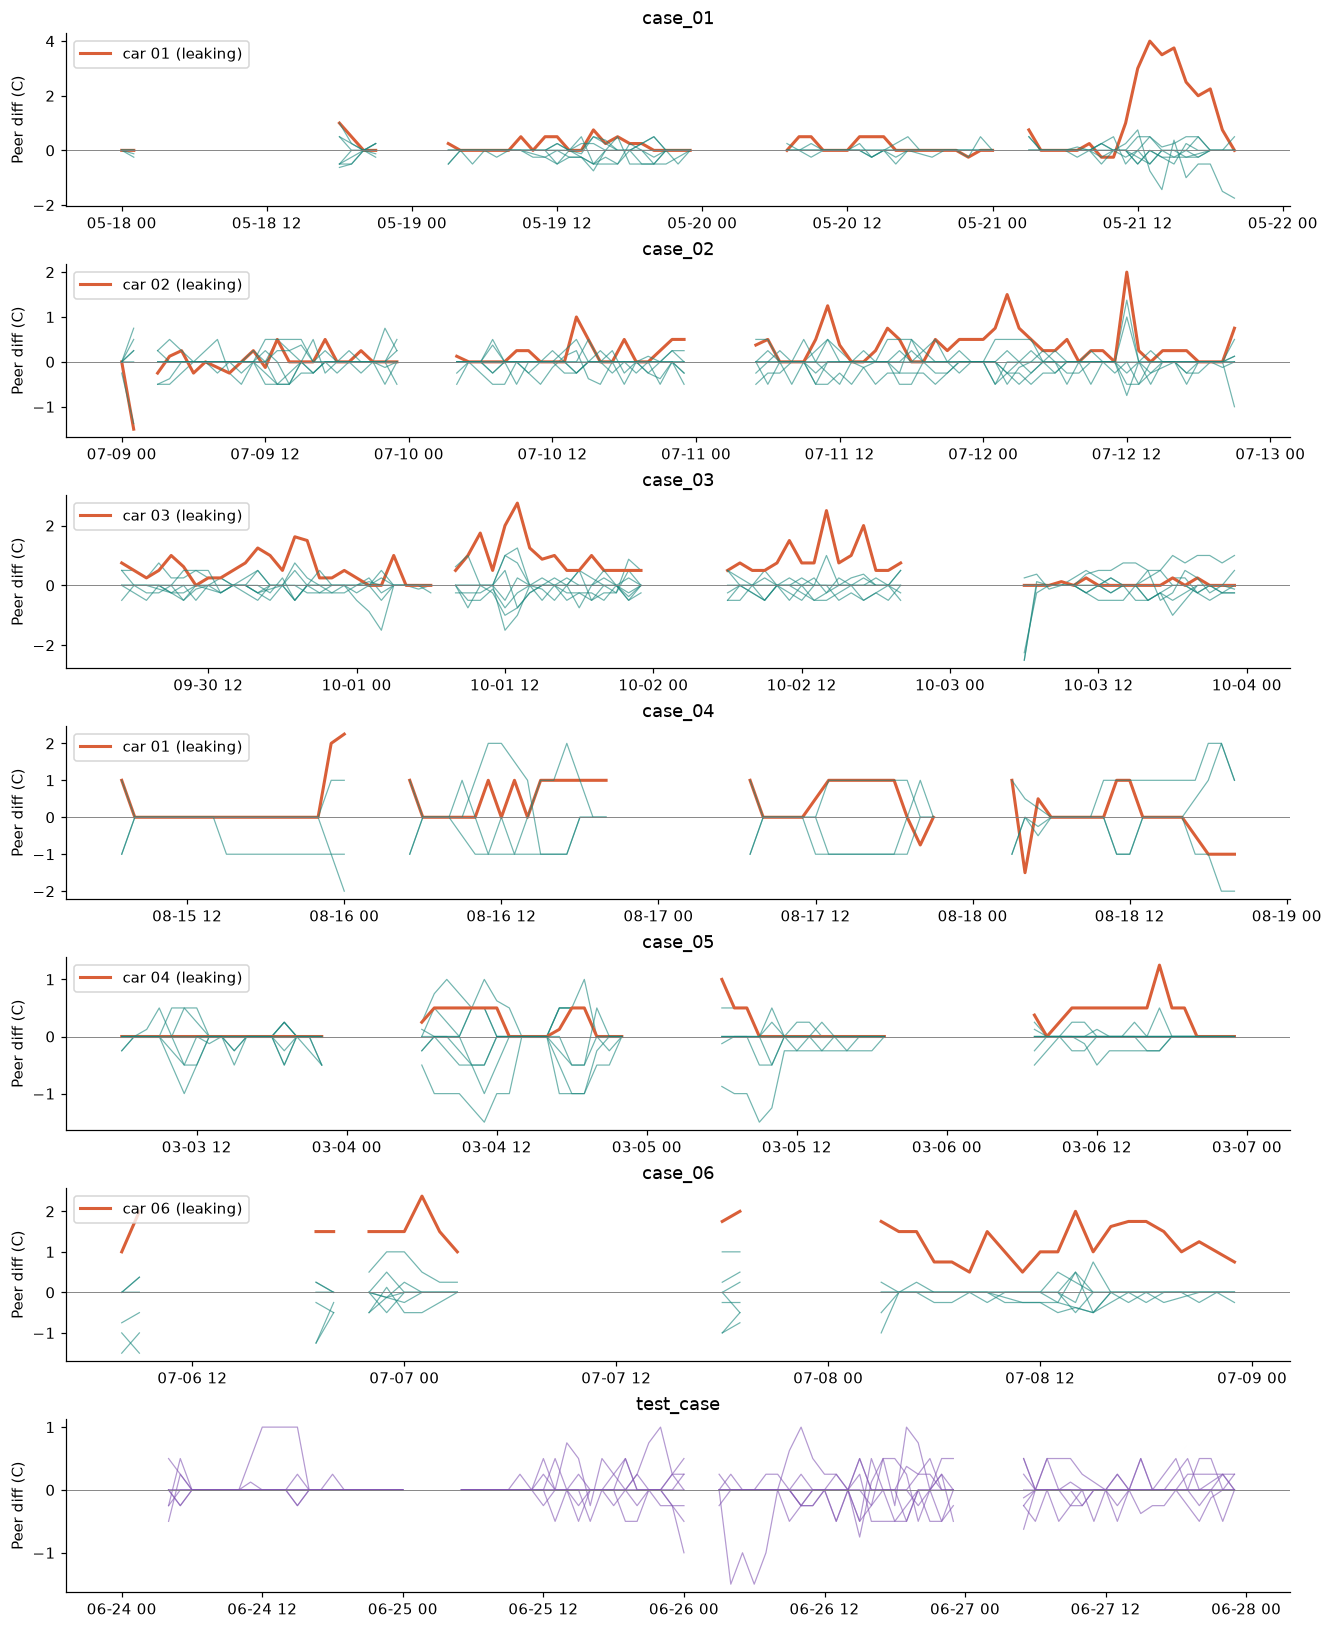

In [32]:
hourly = (grid[grid['cooling']].assign(hour_start=lambda g: g['minute'].dt.floor('1h'))
          .groupby(['case', 'car', 'hour_start'])['peer_delta'].median())
cases = train_cases + ['test_case']
fig, axes = plt.subplots(len(cases), 1, figsize=(12, 2.1 * len(cases)))
for ax, case in zip(axes, cases):
    block = hourly.loc[case]
    starts = block.index.get_level_values('hour_start')
    hours = pd.date_range(starts.min(), starts.max(), freq='1h')
    for car, series in block.groupby(level='car'):
        values = series.droplevel('car').reindex(hours)  # hours without cooling data break the line
        affected = label_map.get(case) == car
        color = COLORS['Test car'] if case == 'test_case' else COLORS['Affected car' if affected else 'Other car']
        ax.plot(hours, values.to_numpy(), color=color, linewidth=2 if affected else 0.8,
                alpha=1 if affected else 0.6, label=f'car {car} (leaking)' if affected else None)
    ax.axhline(0, color='grey', linewidth=0.6)
    ax.set(ylabel='Peer diff (C)', title=case)
    if case in label_map:
        ax.legend(loc='upper left')
plt.show()

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-8" style="color: black;"><b>Section 8: Export</b></h2>
</div>

This section writes the prepared tables to Parquet, records a manifest of settings and sources, and
verifies that every file reads back identically.

<blockquote><h3 id="8-1"><b>8.1 Output Tables</b></h3></blockquote>

In the cell below, four tables are written: the cleaned readings at native cadence, the one-minute grid
with peer and context features, the case-and-car feature table with labels and folds, and the parameter
mapping. Text columns are stored with the pandas string type so that missing values round-trip
consistently.

In [33]:
def for_parquet(frame):
    """Copy of `frame` with object columns converted to the pandas string dtype."""
    out = frame.reset_index(drop=True).copy()
    for column in out.columns[out.dtypes.eq(object)]:
        out[column] = out[column].astype('string')
    return out


long_out = long.merge(case_meta[['case', 'dataset', 'car_model']], on='case', how='left')
outputs = {
    'acv_readings.parquet': for_parquet(long_out),
    'acv_minutes.parquet': for_parquet(grid),
    'acv_car_features.parquet': for_parquet(features),
    'acv_parameter_mapping.parquet': for_parquet(mapping),
}
for name, frame in outputs.items():
    frame.to_parquet(OUT_DIR / name, index=False)
display(pd.DataFrame([{'file': name, 'rows': len(frame), 'columns': frame.shape[1],
                       'size_MB': round((OUT_DIR / name).stat().st_size / 1e6, 3)} for name, frame in outputs.items()]))

,file,rows,columns,size_MB
0,acv_readings.parquet,408517,16,2.422
1,acv_minutes.parquet,182284,16,1.030
2,acv_car_features.parquet,56,39,0.033
3,acv_parameter_mapping.parquet,392,6,0.005


<blockquote><h3 id="8-2"><b>8.2 Manifest</b></h3></blockquote>

In the cell below, a JSON manifest records the source fingerprints, the preprocessing settings and the
size of each output.

In [34]:
manifest = {
    'subsystem': 'ACV',
    'sources': dict(zip(inventory['workbook'], inventory['sha256'])),
    'settings': {'seed': SEED, 'grid': GRID, 'min_peers': MIN_PEERS, 'hot_quantile': 0.75,
                 'above_target_margin_C': 1.0, 'aliases': ALIASES, 'mode_groups': MODE_GROUPS,
                 'invalid_rule': 'valid/mode/setting == Invalid, or any temperature <= 0',
                 'folds': 'leave one Train case out', 'features': FEATURES},
    'outputs': {name: {'rows': len(frame), 'columns': frame.shape[1]} for name, frame in outputs.items()},
}
(OUT_DIR / 'manifest.json').write_text(json.dumps(manifest, indent=2))
print(json.dumps({k: manifest['settings'][k] for k in ['grid', 'min_peers', 'hot_quantile', 'invalid_rule', 'folds']}, indent=2))

{
  "grid": "1min",
  "min_peers": 3,
  "hot_quantile": 0.75,
  "invalid_rule": "valid/mode/setting == Invalid, or any temperature <= 0",
  "folds": "leave one Train case out"
}


<blockquote><h3 id="8-3"><b>8.3 Export Verification</b></h3></blockquote>

In the cell below, each Parquet file is read back and compared with the table in memory.

In [35]:
for name, frame in outputs.items():
    pd.testing.assert_frame_equal(pd.read_parquet(OUT_DIR / name), frame)
print('All outputs read back identically.')

All outputs read back identically.


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-9" style="color: black;"><b>Section 9: Conclusions</b></h2>
</div>

This section summarises the prepared outputs, the data-quality findings, and their implications for
ranking models. All statements refer to the executed results above.

<blockquote><h3 id="9-1"><b>9.1 Prepared Outputs</b></h3></blockquote>

- `acv_readings.parquet` holds 408,517 cleaned readings at native cadence with the common fields,
  operating state, invalid flag and train-level outdoor temperature.
- `acv_minutes.parquet` holds 182,284 one-minute rows with the peer median, peer count, peer
  difference, target error and cooling and hot flags.
- `acv_car_features.parquet` holds 56 case-and-car rows (48 Train, 8 Test) with ten features, their
  within-case z-scores and ranks, labels, leave-one-case-out folds and car model.
  `acv_parameter_mapping.parquet` records the source of every common field for every car.
- Every file reads back identically, and `manifest.json` records the source fingerprints, the field
  mapping, the mode groups and the cleaning rules.

<blockquote><h3 id="9-2"><b>9.2 Data Quality Findings</b></h3></blockquote>

- The seven workbooks come from three car models: model A (`case_01` to `case_03` and `test_case`,
  trains 620, 620, 619 and 620), model B (`case_04`, train 208) and model C (`case_05` and `case_06`,
  trains 407 and 408). Only `ACV Running Mode` appears in every workbook, and 62 of the 63 parameters
  of `case_04` appear nowhere else.
- Car columns are not in numeric order, and the order differs between car models, so cars must be
  identified from the header text and never by column position.
- Timestamps are complete, unique and increasing. The modal step is 30 seconds (10 seconds in
  `case_04`), with 5 to 10 gaps longer than five minutes per case and longest gaps of 358.5 to 680.5
  minutes. The one-minute grid holds data in 39.4% (`case_06`) to 77.7% (`case_03`) of the minutes
  spanned.
- Silence is train-wide: the share of timestamps at which every car is silent (1.9% in `case_04` to
  13.7% in `case_06`) matches the share for each reporting car to one decimal place, and `case_03` has
  no silent timestamps. Cars 05 to 08 of `case_04` are silent throughout.
- In model C, the outside temperature is numeric only for cars 01 and 08 and reads `Invalid` for the
  other six cars. The train-level outdoor temperature nevertheless covers 100.0% of timestamps in every
  case after rounding.
- Every zero temperature (25, 44, 1 and 25 readings in `case_01`, `case_02`, `case_03` and
  `test_case`) coincides with an `Invalid` flag, so the flag-based mask removes the sentinel values;
  56, 49, 1 and 26 readings are masked in total.
- In `case_04`, the observation-area temperature is negative in 65,540 of 87,389 readings, with a
  minimum and median of -50, which supports mapping the passenger cabin temperature to the indoor
  field.

<blockquote><h3 id="9-3"><b>9.3 Implications for Modelling</b></h3></blockquote>

- In the Train cases, the leaking car has the strictly highest mean peer difference during hot cooling
  minutes in all six cases, and the strictly highest mean target error, share of minutes above target
  and mean peer difference while cooling in five cases, ranking second in `case_04`. These are in-sample
  descriptions of six cases, not validated performance, and they should be tested as simple ranking
  rules under leave-one-case-out evaluation before any learned model.
- The cooling share (median rank 6) and the full-cooling share (strictly highest in no case) do not
  single out the leaking car.
- The pressure cross-check does not clearly support the `case_04` label: the labelled car 01 has the
  lowest system 2 high-side pressure (1,560 against 1,900 to 2,020), but car 04 has the lowest low-side
  pressures in both systems (400 and 340). As the only model B case, with half of its cars silent,
  `case_04` should be evaluated both with and without inclusion.
- The four silent cars of `case_04` have no features, so a ranking model must place such cars
  explicitly. All eight Test cars have cabin temperature for at least 99.8% of their kept readings.